In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import r2_score,mean_squared_error

In [2]:
df=pd.read_csv('C:\\Users\\Sowndarya\\OneDrive\\Desktop\\DataAnalytics\\AI&ML\\Project-ML\\Regression_dataset\\student_placement.csv')

In [3]:
df

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,IT,Tier-3,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,2,3,2,0,0,3,0,NaN
99996,IT,Tier-3,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,1,2,3,0,1,0,1,16.58
99997,EE,Tier-2,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,0,2,1,0,1,2,1,17.24
99998,ME,Tier-3,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,1,4,2,0,0,1,1,17.01


In [4]:
df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


In [5]:
df.tail()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
99995,IT,Tier-3,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,2,3,2,0,0,3,0,NaN
99996,IT,Tier-3,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,1,2,3,0,1,0,1,16.58
99997,EE,Tier-2,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,0,2,1,0,1,2,1,17.24
99998,ME,Tier-3,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,1,4,2,0,0,1,1,17.01
99999,ECE,Tier-1,7.00,0,2.8,5.3,64.5,5.7,5.7,3.4,0,2,2,2,0,1,1,14.98


In [6]:
df.shape

(100000, 18)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     100000 non-null  object 
 1   college_tier               100000 non-null  object 
 2   cgpa                       100000 non-null  float64
 3   backlogs                   100000 non-null  int64  
 4   coding_skills              100000 non-null  float64
 5   dsa_score                  100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skills       100000 non-null  float64
 8   ml_knowledge               100000 non-null  float64
 9   system_design              100000 non-null  float64
 10  internships                100000 non-null  int64  
 11  projects_count             100000 non-null  int64  
 12  certifications             100000 non-null  int64  
 13  hackathons                 100

In [8]:
df.describe()

,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,68475.000000
mean,7.206381,0.547010,5.995147,5.500711,64.990511,5.990614,4.508752,4.008210,1.095040,2.397280,1.49985,0.745840,0.450990,1.151100,0.684750,17.308014
std,0.925235,0.862727,1.496302,1.781961,11.990892,1.496552,1.968278,1.778405,0.940264,1.242829,1.11407,0.884189,0.671061,0.965162,0.464618,2.601041
min,4.000000,0.000000,1.000000,1.000000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,6.880000
25%,6.580000,0.000000,5.000000,4.300000,56.800000,5.000000,3.200000,2.800000,0.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,15.530000
50%,7.210000,0.000000,6.000000,5.500000,65.000000,6.000000,4.500000,4.000000,1.000000,2.000000,1.00000,0.000000,0.000000,1.000000,1.000000,17.250000
75%,7.830000,1.000000,7.000000,6.700000,73.100000,7.000000,5.900000,5.200000,2.000000,3.000000,2.00000,1.000000,1.000000,2.000000,1.000000,19.040000
max,10.000000,3.000000,10.000000,10.000000,100.000000,10.000000,10.000000,10.000000,3.000000,5.000000,4.00000,3.000000,2.000000,3.000000,1.000000,28.330000


In [9]:
df.isnull().sum()

branch                           0
college_tier                     0
cgpa                             0
backlogs                         0
coding_skills                    0
dsa_score                        0
aptitude_score                   0
communication_skills             0
ml_knowledge                     0
system_design                    0
internships                      0
projects_count                   0
certifications                   0
hackathons                       0
open_source_contributions        0
extracurriculars                 0
placement_status                 0
salary_package_lpa           31525
dtype: int64

In [10]:
df['salary_package_lpa'].fillna(df['salary_package_lpa'].mean(),inplace=True)

C:\Users\Sowndarya\AppData\Local\Temp\ipykernel_22080\4163330855.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['salary_package_lpa'].fillna(df['salary_package_lpa'].mean(),inplace=True)


In [11]:
df.isnull().sum()

branch                       0
college_tier                 0
cgpa                         0
backlogs                     0
coding_skills                0
dsa_score                    0
aptitude_score               0
communication_skills         0
ml_knowledge                 0
system_design                0
internships                  0
projects_count               0
certifications               0
hackathons                   0
open_source_contributions    0
extracurriculars             0
placement_status             0
salary_package_lpa           0
dtype: int64

In [12]:
df.dtypes

branch                        object
college_tier                  object
cgpa                         float64
backlogs                       int64
coding_skills                float64
dsa_score                    float64
aptitude_score               float64
communication_skills         float64
ml_knowledge                 float64
system_design                float64
internships                    int64
projects_count                 int64
certifications                 int64
hackathons                     int64
open_source_contributions      int64
extracurriculars               int64
placement_status               int64
salary_package_lpa           float64
dtype: object

In [13]:
le=LabelEncoder()

In [15]:
df['branch']=le.fit_transform(df['branch'])
df['college_tier']=le.fit_transform(df['college_tier'])

In [16]:
df.dtypes

branch                         int64
college_tier                   int64
cgpa                         float64
backlogs                       int64
coding_skills                float64
dsa_score                    float64
aptitude_score               float64
communication_skills         float64
ml_knowledge                 float64
system_design                float64
internships                    int64
projects_count                 int64
certifications                 int64
hackathons                     int64
open_source_contributions      int64
extracurriculars               int64
placement_status               int64
salary_package_lpa           float64
dtype: object

In [19]:
x=df.drop(columns='salary_package_lpa',axis=1)
y=df['salary_package_lpa']

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [21]:
model=LinearRegression()

In [22]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
y_pred=model.predict(x_test)
print(y_pred)

[15.11740545 19.40264886 15.4073227  ... 15.12338695 16.04957337
 17.8603115 ]


In [26]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [27]:
print(f"mse:",mse)
print(f"r2_score:",r2)

mse: 2.11476320120565
r2_score: 0.538785664424184


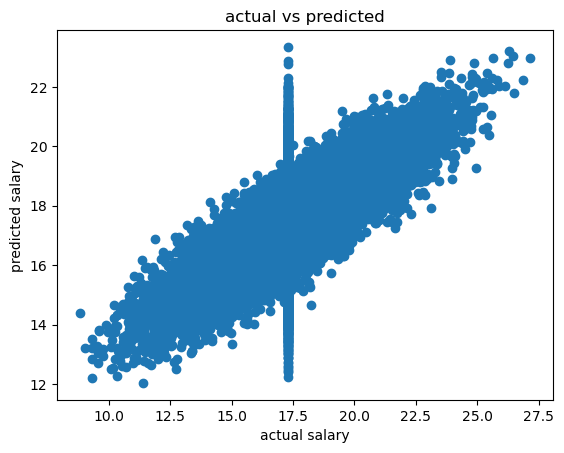

In [29]:
plt.figure()
plt.scatter(y_test,y_pred)
plt.xlabel("actual salary")
plt.ylabel("predicted salary")
plt.title("actual vs predicted")
plt.show()

In [33]:
df.head(4)

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,3,2,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.750000
1,2,1,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,17.308014
2,4,1,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.060000
3,0,1,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,17.308014


In [34]:
new_data=[[3,1,8.5,0,9,5,80,7.5,6.5,6.6,4,4,4,2,1,2,1]]

In [43]:
output_prdctn=model.predict(new_data)
print(np.round(output_prdctn,2))

[22.46]


C:\Users\Sowndarya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [46]:
print(f"student salary package:",np.round(output_prdctn,2),"LPA")

student salary package: [22.46] LPA
